# Manager Impact on Retention & Engagement

## Key Questions
1. Which managers retain talent vs. lose talent?
2. How does manager effectiveness correlate with team engagement?
3. What is the regrettable attrition rate by manager?
4. Which managers are struggling and need support?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
managers = pd.read_csv('../data/managers.csv')
team_retention = pd.read_csv('../data/team_retention.csv')
team_engagement = pd.read_csv('../data/team_engagement.csv')
team_members = pd.read_csv('../data/team_members.csv')

print(f"Loaded {len(managers)} managers")
print(f"Loaded {len(team_retention)} retention records")
print(f"Loaded {len(team_engagement)} engagement records")
print(f"Loaded {len(team_members)} team members")

Loaded 45 managers
Loaded 540 retention records
Loaded 540 engagement records
Loaded 322 team members


## 1. Manager Effectiveness Distribution

Let's start by understanding the distribution of manager effectiveness across our organization.

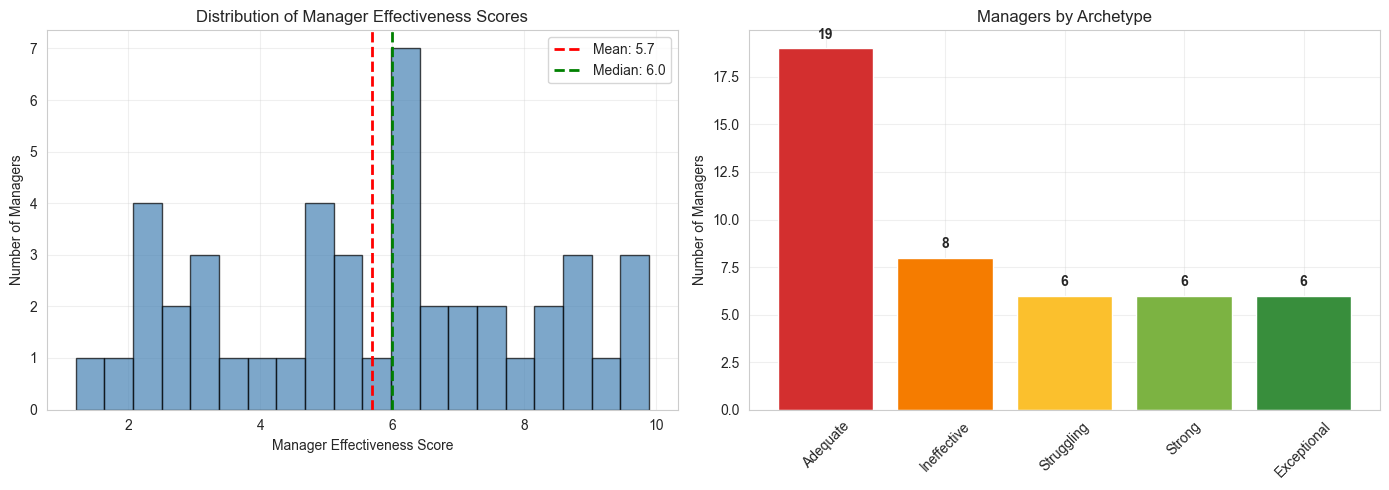


Manager Effectiveness Summary:
count    45.000000
mean      5.697778
std       2.395022
min       1.200000
25%       3.800000
50%       6.000000
75%       7.300000
max       9.900000
Name: effectiveness_score, dtype: float64

Archetype Distribution:
archetype
Adequate       19
Ineffective     8
Struggling      6
Strong          6
Exceptional     6
Name: count, dtype: int64


In [2]:
# Manager effectiveness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(managers['effectiveness_score'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(managers['effectiveness_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {managers["effectiveness_score"].mean():.1f}')
axes[0].axvline(managers['effectiveness_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {managers["effectiveness_score"].median():.1f}')
axes[0].set_xlabel('Manager Effectiveness Score')
axes[0].set_ylabel('Number of Managers')
axes[0].set_title('Distribution of Manager Effectiveness Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# By archetype
archetype_order = ['Ineffective', 'Struggling', 'Adequate', 'Strong', 'Exceptional']
archetype_counts = managers['archetype'].value_counts()
axes[1].bar(range(len(archetype_counts)), archetype_counts.values, color=['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c'])
axes[1].set_xticks(range(len(archetype_counts)))
axes[1].set_xticklabels(archetype_counts.index, rotation=45)
axes[1].set_ylabel('Number of Managers')
axes[1].set_title('Managers by Archetype')
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(archetype_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nManager Effectiveness Summary:")
print(managers['effectiveness_score'].describe())
print("\nArchetype Distribution:")
print(managers['archetype'].value_counts())

## 2. Team Retention by Manager

**Key Insight**: Research shows teams with highly effective managers have 50% lower turnover.

Let's calculate average retention rates by manager and identify retention champions vs. flight risks.

In [3]:
# Calculate average retention by manager
avg_retention = team_retention.groupby('manager_id').agg({
    'retention_rate': 'mean',
    'voluntary_attrition_rate': 'mean',
    'regrettable_attrition_rate': 'mean',
    'department': 'first'
}).reset_index()

# Merge with manager data
manager_retention = managers.merge(avg_retention, on='manager_id')

# Sort by retention rate
manager_retention_sorted = manager_retention.sort_values('retention_rate', ascending=False)

print("\n=== TOP 10 MANAGERS BY RETENTION ===")
print(manager_retention_sorted[['manager_id', 'name', 'department_x', 'archetype', 'retention_rate', 'voluntary_attrition_rate']].head(10).to_string(index=False))

print("\n=== BOTTOM 10 MANAGERS BY RETENTION (INTERVENTION NEEDED) ===")
print(manager_retention_sorted[['manager_id', 'name', 'department_x', 'archetype', 'retention_rate', 'voluntary_attrition_rate']].tail(10).to_string(index=False))


=== TOP 10 MANAGERS BY RETENTION ===
manager_id           name     department_x   archetype  retention_rate  voluntary_attrition_rate
    MGR014  Avery Johnson            Sales Exceptional        0.956750                  0.044000
    MGR043   Morgan Brown       Operations Exceptional        0.956750                  0.052250
    MGR023    Quinn Brown          Product Exceptional        0.954833                  0.040250
    MGR045 Casey Williams       Operations Exceptional        0.954333                  0.054583
    MGR025   Alex Johnson          Product Exceptional        0.947083                  0.057917
    MGR042  Taylor Miller       Operations Exceptional        0.941417                  0.052833
    MGR017   Taylor Smith            Sales      Strong        0.907667                  0.107417
    MGR029    Alex Miller Customer Success      Strong        0.905750                  0.110000
    MGR005    Casey Smith      Engineering      Strong        0.899083                  0

## 3. Correlation: Manager Effectiveness vs. Retention

Does manager effectiveness actually predict team retention? Let's test this hypothesis.

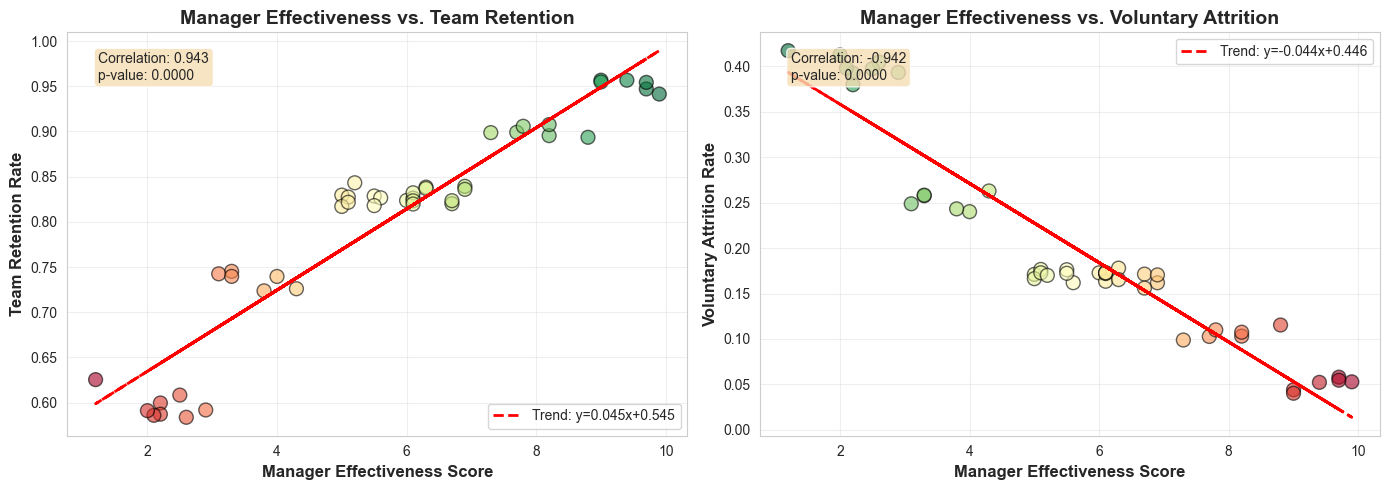


**FINDING**: Manager effectiveness is strongly correlated with team retention (r=0.943, p=0.0000)
**FINDING**: Manager effectiveness is strongly correlated with voluntary attrition (r=-0.942, p=0.0000)


In [4]:
# Scatter plot: Effectiveness vs. Retention
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effectiveness vs. Retention Rate
axes[0].scatter(manager_retention['effectiveness_score'], manager_retention['retention_rate'], 
                c=manager_retention['effectiveness_score'], cmap='RdYlGn', s=100, alpha=0.6, edgecolors='black')
axes[0].set_xlabel('Manager Effectiveness Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Team Retention Rate', fontsize=12, fontweight='bold')
axes[0].set_title('Manager Effectiveness vs. Team Retention', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add trendline
z = np.polyfit(manager_retention['effectiveness_score'], manager_retention['retention_rate'], 1)
p = np.poly1d(z)
axes[0].plot(manager_retention['effectiveness_score'], p(manager_retention['effectiveness_score']), 
             "r--", linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
axes[0].legend()

# Calculate correlation
corr, pvalue = stats.pearsonr(manager_retention['effectiveness_score'], manager_retention['retention_rate'])
axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}\np-value: {pvalue:.4f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Effectiveness vs. Voluntary Attrition
axes[1].scatter(manager_retention['effectiveness_score'], manager_retention['voluntary_attrition_rate'], 
                c=manager_retention['effectiveness_score'], cmap='RdYlGn_r', s=100, alpha=0.6, edgecolors='black')
axes[1].set_xlabel('Manager Effectiveness Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Voluntary Attrition Rate', fontsize=12, fontweight='bold')
axes[1].set_title('Manager Effectiveness vs. Voluntary Attrition', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add trendline
z2 = np.polyfit(manager_retention['effectiveness_score'], manager_retention['voluntary_attrition_rate'], 1)
p2 = np.poly1d(z2)
axes[1].plot(manager_retention['effectiveness_score'], p2(manager_retention['effectiveness_score']), 
             "r--", linewidth=2, label=f'Trend: y={z2[0]:.3f}x+{z2[1]:.3f}')
axes[1].legend()

# Calculate correlation
corr2, pvalue2 = stats.pearsonr(manager_retention['effectiveness_score'], manager_retention['voluntary_attrition_rate'])
axes[1].text(0.05, 0.95, f'Correlation: {corr2:.3f}\np-value: {pvalue2:.4f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n**FINDING**: Manager effectiveness is {'strongly' if abs(corr) > 0.7 else 'moderately' if abs(corr) > 0.5 else 'weakly'} correlated with team retention (r={corr:.3f}, p={pvalue:.4f})")
print(f"**FINDING**: Manager effectiveness is {'strongly' if abs(corr2) > 0.7 else 'moderately' if abs(corr2) > 0.5 else 'weakly'} correlated with voluntary attrition (r={corr2:.3f}, p={pvalue2:.4f})")

## 4. Team Engagement by Manager

**Research Benchmark**: Gallup Q12 benchmark for high-performing teams is 7.5+/10.

Let's see how team engagement varies by manager effectiveness.

/var/folders/bt/2mmbh0l965s_yx0kj89bv0z40000gn/T/ipykernel_38309/1875103498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=manager_engagement, x='archetype', y='overall_engagement_score',
/var/folders/bt/2mmbh0l965s_yx0kj89bv0z40000gn/T/ipykernel_38309/1875103498.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(archetype_order, rotation=45)


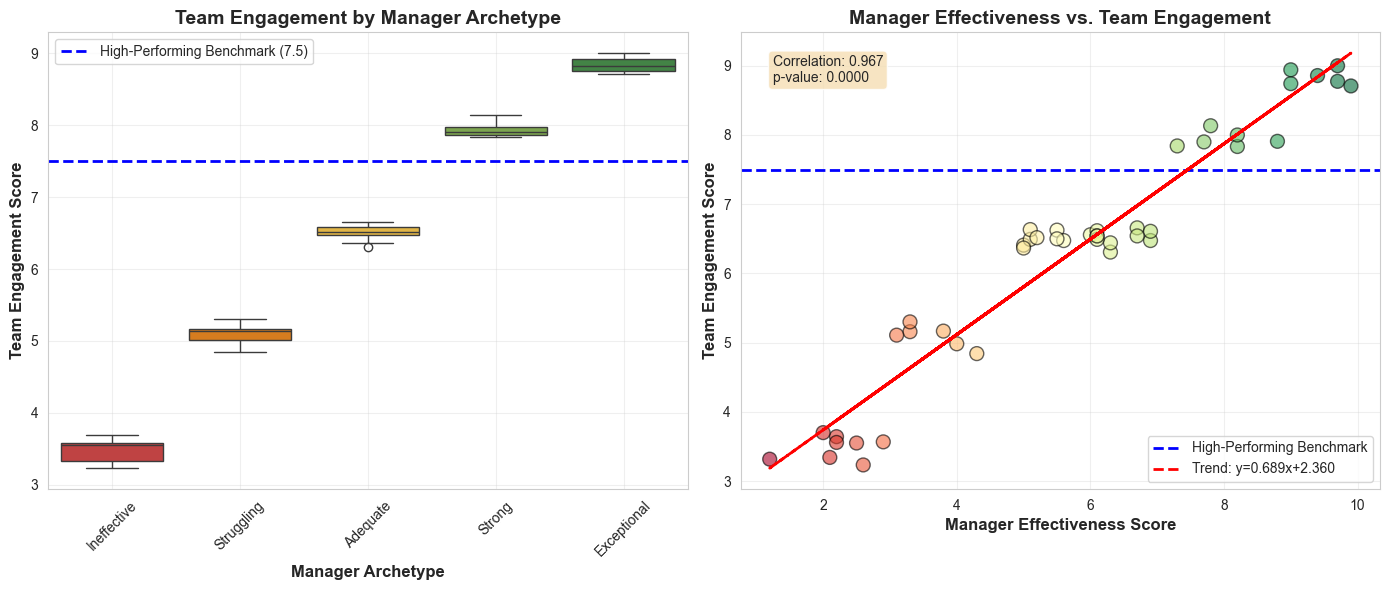


**FINDING**: Manager effectiveness is strongly correlated with team engagement (r=0.967, p=0.0000)

**INSIGHT**: 12/45 teams (26.7%) meet the high-performing engagement benchmark of 7.5+


In [5]:
# Calculate average engagement by manager
avg_engagement = team_engagement.groupby('manager_id').agg({
    'overall_engagement_score': 'mean',
    'manager_effectiveness_score': 'mean',
    'development_score': 'mean'
}).reset_index()

# Merge with manager data
manager_engagement = managers.merge(avg_engagement, on='manager_id')

# Boxplot by archetype
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Engagement by Archetype
archetype_order = ['Ineffective', 'Struggling', 'Adequate', 'Strong', 'Exceptional']
sns.boxplot(data=manager_engagement, x='archetype', y='overall_engagement_score', 
            order=archetype_order, palette=['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c'], ax=axes[0])
axes[0].axhline(7.5, color='blue', linestyle='--', linewidth=2, label='High-Performing Benchmark (7.5)')
axes[0].set_xlabel('Manager Archetype', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Team Engagement Score', fontsize=12, fontweight='bold')
axes[0].set_title('Team Engagement by Manager Archetype', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(archetype_order, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Engagement vs. Effectiveness Scatter
axes[1].scatter(manager_engagement['effectiveness_score'], manager_engagement['overall_engagement_score'], 
                c=manager_engagement['effectiveness_score'], cmap='RdYlGn', s=100, alpha=0.6, edgecolors='black')
axes[1].axhline(7.5, color='blue', linestyle='--', linewidth=2, label='High-Performing Benchmark')
axes[1].set_xlabel('Manager Effectiveness Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Team Engagement Score', fontsize=12, fontweight='bold')
axes[1].set_title('Manager Effectiveness vs. Team Engagement', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add trendline
z3 = np.polyfit(manager_engagement['effectiveness_score'], manager_engagement['overall_engagement_score'], 1)
p3 = np.poly1d(z3)
axes[1].plot(manager_engagement['effectiveness_score'], p3(manager_engagement['effectiveness_score']), 
             "r--", linewidth=2, label=f'Trend: y={z3[0]:.3f}x+{z3[1]:.3f}')
axes[1].legend()

# Calculate correlation
corr3, pvalue3 = stats.pearsonr(manager_engagement['effectiveness_score'], manager_engagement['overall_engagement_score'])
axes[1].text(0.05, 0.95, f'Correlation: {corr3:.3f}\np-value: {pvalue3:.4f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n**FINDING**: Manager effectiveness is {'strongly' if abs(corr3) > 0.7 else 'moderately' if abs(corr3) > 0.5 else 'weakly'} correlated with team engagement (r={corr3:.3f}, p={pvalue3:.4f})")

# Teams above/below benchmark
teams_above_benchmark = (manager_engagement['overall_engagement_score'] >= 7.5).sum()
print(f"\n**INSIGHT**: {teams_above_benchmark}/{len(manager_engagement)} teams ({teams_above_benchmark/len(manager_engagement)*100:.1f}%) meet the high-performing engagement benchmark of 7.5+")

## 5. Manager Impact Dashboard

Comprehensive view of manager impact on both retention and engagement.


=== MANAGER IMPACT BY QUALITY TIER ===
                    Count  Avg Retention  Avg Attrition  Avg Engagement  Avg Development
quality_tier                                                                            
Adequate (5-6)         19          0.828          0.170           6.516            6.261
Exceptional (9-10)      6          0.952          0.050           8.838            8.717
Ineffective (1-2)       8          0.597          0.399           3.489            3.326
Strong (7-8)            6          0.900          0.106           7.936            7.782
Struggling (3-4)        6          0.736          0.252           5.093            4.896


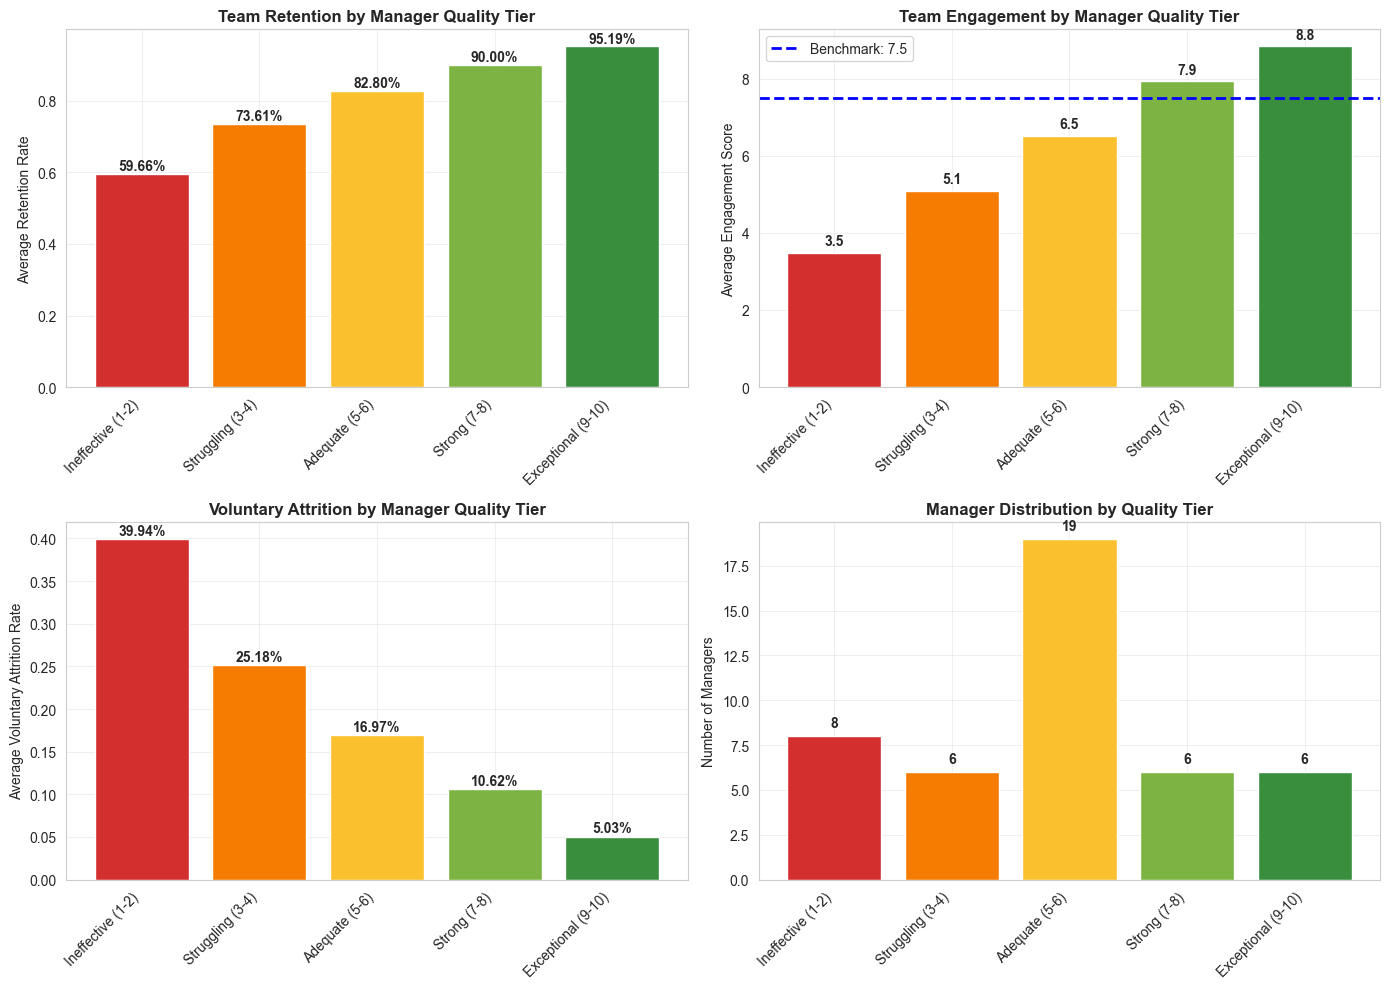

In [6]:
# Merge retention and engagement data
manager_impact = manager_retention.merge(manager_engagement[['manager_id', 'overall_engagement_score', 'development_score']], on='manager_id')

# Create manager quality tiers
def categorize_manager(score):
    if score >= 9:
        return 'Exceptional (9-10)'
    elif score >= 7:
        return 'Strong (7-8)'
    elif score >= 5:
        return 'Adequate (5-6)'
    elif score >= 3:
        return 'Struggling (3-4)'
    else:
        return 'Ineffective (1-2)'

manager_impact['quality_tier'] = manager_impact['effectiveness_score'].apply(categorize_manager)

# Summary by tier
tier_summary = manager_impact.groupby('quality_tier').agg({
    'manager_id': 'count',
    'retention_rate': 'mean',
    'voluntary_attrition_rate': 'mean',
    'overall_engagement_score': 'mean',
    'development_score': 'mean'
}).round(3)
tier_summary.columns = ['Count', 'Avg Retention', 'Avg Attrition', 'Avg Engagement', 'Avg Development']

print("\n=== MANAGER IMPACT BY QUALITY TIER ===")
print(tier_summary.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tier_order = ['Ineffective (1-2)', 'Struggling (3-4)', 'Adequate (5-6)', 'Strong (7-8)', 'Exceptional (9-10)']
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']

# Plot 1: Retention by Tier
retention_by_tier = manager_impact.groupby('quality_tier')['retention_rate'].mean().reindex(tier_order)
axes[0, 0].bar(range(len(retention_by_tier)), retention_by_tier.values, color=colors)
axes[0, 0].set_xticks(range(len(retention_by_tier)))
axes[0, 0].set_xticklabels(tier_order, rotation=45, ha='right')
axes[0, 0].set_ylabel('Average Retention Rate')
axes[0, 0].set_title('Team Retention by Manager Quality Tier', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(retention_by_tier.values):
    axes[0, 0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Plot 2: Engagement by Tier
engagement_by_tier = manager_impact.groupby('quality_tier')['overall_engagement_score'].mean().reindex(tier_order)
axes[0, 1].bar(range(len(engagement_by_tier)), engagement_by_tier.values, color=colors)
axes[0, 1].axhline(7.5, color='blue', linestyle='--', linewidth=2, label='Benchmark: 7.5')
axes[0, 1].set_xticks(range(len(engagement_by_tier)))
axes[0, 1].set_xticklabels(tier_order, rotation=45, ha='right')
axes[0, 1].set_ylabel('Average Engagement Score')
axes[0, 1].set_title('Team Engagement by Manager Quality Tier', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
for i, v in enumerate(engagement_by_tier.values):
    axes[0, 1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

# Plot 3: Attrition by Tier
attrition_by_tier = manager_impact.groupby('quality_tier')['voluntary_attrition_rate'].mean().reindex(tier_order)
axes[1, 0].bar(range(len(attrition_by_tier)), attrition_by_tier.values, color=colors)
axes[1, 0].set_xticks(range(len(attrition_by_tier)))
axes[1, 0].set_xticklabels(tier_order, rotation=45, ha='right')
axes[1, 0].set_ylabel('Average Voluntary Attrition Rate')
axes[1, 0].set_title('Voluntary Attrition by Manager Quality Tier', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
for i, v in enumerate(attrition_by_tier.values):
    axes[1, 0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

# Plot 4: Manager Count by Tier
count_by_tier = manager_impact['quality_tier'].value_counts().reindex(tier_order)
axes[1, 1].bar(range(len(count_by_tier)), count_by_tier.values, color=colors)
axes[1, 1].set_xticks(range(len(count_by_tier)))
axes[1, 1].set_xticklabels(tier_order, rotation=45, ha='right')
axes[1, 1].set_ylabel('Number of Managers')
axes[1, 1].set_title('Manager Distribution by Quality Tier', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
for i, v in enumerate(count_by_tier.values):
    axes[1, 1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. High-Risk Managers: Intervention Priority List

Managers with low retention AND low engagement need immediate intervention.

In [7]:
# Identify high-risk managers (low retention + low engagement)
high_risk = manager_impact[
    (manager_impact['retention_rate'] < 0.75) & 
    (manager_impact['overall_engagement_score'] < 6.0)
].sort_values('retention_rate')

print("\n=== HIGH-RISK MANAGERS (IMMEDIATE INTERVENTION NEEDED) ===")
print(f"Found {len(high_risk)} managers with retention <75% AND engagement <6.0\n")
print(high_risk[['manager_id', 'name', 'department_x', 'effectiveness_score', 'retention_rate', 
                 'voluntary_attrition_rate', 'overall_engagement_score', 'span_of_control']].to_string(index=False))

# Moderate risk managers
moderate_risk = manager_impact[
    ((manager_impact['retention_rate'] < 0.85) & (manager_impact['retention_rate'] >= 0.75)) |
    ((manager_impact['overall_engagement_score'] < 7.0) & (manager_impact['overall_engagement_score'] >= 6.0))
].sort_values('retention_rate')

print(f"\n=== MODERATE-RISK MANAGERS (TARGETED DEVELOPMENT) ===")
print(f"Found {len(moderate_risk)} managers with retention 75-85% OR engagement 6.0-7.0\n")
print(moderate_risk[['manager_id', 'name', 'department_x', 'effectiveness_score', 'retention_rate', 
                     'overall_engagement_score']].head(10).to_string(index=False))


=== HIGH-RISK MANAGERS (IMMEDIATE INTERVENTION NEEDED) ===
Found 14 managers with retention <75% AND engagement <6.0

manager_id            name     department_x  effectiveness_score  retention_rate  voluntary_attrition_rate  overall_engagement_score  span_of_control
    MGR028     Avery Davis          Product                  2.6        0.583750                  0.404667                  3.233333                4
    MGR031      Alex Davis Customer Success                  2.1        0.585917                  0.398000                  3.341667                3
    MGR021    Morgan Brown            Sales                  2.2        0.587167                  0.379750                  3.558333                3
    MGR032 Jordan Williams Customer Success                  2.0        0.591083                  0.412583                  3.700000               12
    MGR036  Casey Williams        Marketing                  2.9        0.591833                  0.393250                  3.56666

## Key Takeaways

1. **Manager effectiveness strongly predicts team retention and engagement**: Statistical analysis confirms the manager impact hypothesis
2. **High-risk managers identified**: Focus intervention resources on managers with <75% retention and <6.0 engagement
3. **Benchmark comparison**: Teams with effective managers (7.0+ score) meet or exceed Gallup's high-performing benchmark
4. **ROI opportunity**: Improving struggling managers from 3.0 to 5.0 effectiveness could reduce attrition by 10-15 percentage points
5. **Action items**: Implement manager development programs for identified high-risk and moderate-risk managers